In [1]:
# =========================================================
# 02_clean_merge.ipynb
# Purpose:
#   - Load the 3 raw datasets
#   - Drop useless columns
#   - Normalize label systems into:
#         0 = negative
#         1 = neutral
#         2 = positive
#   - Remove invalid labels
#   - Standardize column names
#   - Merge into one final clean dataset
#   - Remove duplicates and empty rows
#   - Save outputs for modeling
# =========================================================

In [2]:
# Standard library
from pathlib import Path
import json

# Data analysis
import pandas as pd
import numpy as np

# Optional display improvements
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ---------------------------------------------------------
# Define the base paths of the ML workspace
# ---------------------------------------------------------

ML_ROOT = Path.cwd().parent

RAW_DATA_DIR = ML_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = ML_ROOT / "data" / "processed"
FINAL_DATA_DIR = ML_ROOT / "data" / "final"

print("ML root:", ML_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Final data directory:", FINAL_DATA_DIR)

ML root: C:\Users\hp\Lucidia-project\ml
Raw data directory: C:\Users\hp\Lucidia-project\ml\data\raw
Processed data directory: C:\Users\hp\Lucidia-project\ml\data\processed
Final data directory: C:\Users\hp\Lucidia-project\ml\data\final


In [4]:
# ---------------------------------------------------------
# Define exact dataset file paths
# ---------------------------------------------------------

file_1 = RAW_DATA_DIR / "Algerian Review.csv"
file_2 = RAW_DATA_DIR / "data_2.csv"
file_3 = RAW_DATA_DIR / "data_3.csv"

print(file_1.exists(), "-", file_1.name)
print(file_2.exists(), "-", file_2.name)
print(file_3.exists(), "-", file_3.name)

True - Algerian Review.csv
True - data_2.csv
True - data_3.csv


In [5]:
# ---------------------------------------------------------
# Utility function to load CSV files safely with fallback
# encodings
# ---------------------------------------------------------

def load_csv_safely(file_path: Path) -> pd.DataFrame:
    encodings_to_try = ["utf-8", "utf-8-sig", "latin1", "cp1252"]

    last_error = None
    for enc in encodings_to_try:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f"Loaded {file_path.name} with encoding: {enc}")
            return df
        except Exception as e:
            last_error = e

    raise last_error

In [6]:
# ---------------------------------------------------------
# Load the raw datasets
# ---------------------------------------------------------

df1_raw = load_csv_safely(file_1)
df2_raw = load_csv_safely(file_2)
df3_raw = load_csv_safely(file_3)

print("\nRaw shapes:")
print("df1_raw:", df1_raw.shape)
print("df2_raw:", df2_raw.shape)
print("df3_raw:", df3_raw.shape)

Loaded Algerian Review.csv with encoding: utf-8
Loaded data_2.csv with encoding: utf-8
Loaded data_3.csv with encoding: utf-8

Raw shapes:
df1_raw: (5320, 6)
df2_raw: (1262, 5)
df3_raw: (5782, 7)


In [7]:
# ---------------------------------------------------------
# Preview the first few rows
# ---------------------------------------------------------

print("========== DATASET 1 RAW ==========")
display(df1_raw.head())

print("========== DATASET 2 RAW ==========")
display(df2_raw.head())

print("========== DATASET 3 RAW ==========")
display(df3_raw.head())

========== DATASET 1 RAW ==========


,name,date,likes,comment,sentiment,source
0,djezzy.dz,04/03/20 10:29:29,2309,استفيدوا من عروض جازي عايلة الجديدة لي توالم كامل افراد العائلة 👪 راهي متوفرة في كامل وكالات جازي مع شريحة SIM مجّانية 😱👌🏻 Bénéficiez des nouveaux forfaits DJEZZY 3AYLA qui conviennent à tous les...,0,insta
1,amira_la_bonoise,04/03/20 10:31:18,0,Conx ta3koum dayra ki lhaaaam w say,-1,insta
2,noureddiiiiiine,04/03/20 10:31:38,0,@zaki_medjber_62,0,insta
3,linaragguem,04/03/20 10:32:28,0,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,0,insta
4,samo_oussama,04/03/20 10:36:29,0,🙏😉🙏,1,insta


========== DATASET 2 RAW ==========


,ID,comment,updated_at,like_count,sentiment
0,0,نفس شي مع la win\nتقولو فيسبوك مجاني ....بصح غير يخلاصو لجيغا متقدرش تتفرج فيديوهات,2022-03-30T16:54:00Z,3,1
1,1,غير نلقاو الكونيكسيو و من بعد ساهل,2022-03-30T16:23:00Z,2,1
2,2,نقدر نحول مبتسم تاعي ل سما,2022-03-30T17:08:00Z,0,0
3,3,نسقسيكم برك كان عندي 16 نيوم ملي فليكسيت 1000 دج و اكتيفيت لاوين 650 دج درك لقيت 1 دج 350دج وين راحو ماني دايرة لا رنتي لا هم يحزنون وين راحو دراهمي,2022-03-30T16:54:00Z,2,1
4,4,علاه تخلو الناس تفليكسي 🙄من بعد تدولهم كيما انا منيش دايرة رناتي و كلما نفليكسي تدولي 🙄 ؟!!,2022-03-31T14:15:00Z,2,1


========== DATASET 3 RAW ==========


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,comment,updated_at,like_count,sentiment
0,0,0,0.0,بالنسبة لجماعة هايلة بزاف عرض 1200الف اكتيفيه ب امتياز #444*يعطوك 30جيقا ماشي 20جيقا وشكرا خاوتي.........,2020-07-25T13:06:49Z,24.0,0.0
1,1,1,1.0,نحوها,2022-03-07T17:37:38Z,0.0,0.0
2,2,2,2.0,ماكسي بيسك بزاف مافيهاش 20g,2021-08-18T18:46:32Z,0.0,1.0
3,3,3,3.0,انا عندي هايلة و الماكسي و في 2 في حالة..الحل الوحيد هو لازم يدخلو الشركات الاجنبية كيما اورنج طيح عليهم البق سرعة انترنت خرافية و سعر مغري .,2019-11-19T20:01:56Z,11.0,0.0
4,4,4,4.0,ههههه جيت هنا,2021-10-19T01:45:12Z,0.0,0.0


In [8]:
# ---------------------------------------------------------
# Remove "Unnamed" columns created by CSV exports
# ---------------------------------------------------------

def drop_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    unnamed_cols = [col for col in df.columns if str(col).lower().startswith("unnamed")]
    if unnamed_cols:
        print("Dropping unnamed columns:", unnamed_cols)
    return df.drop(columns=unnamed_cols, errors="ignore")

df1 = drop_unnamed_columns(df1_raw.copy())
df2 = drop_unnamed_columns(df2_raw.copy())
df3 = drop_unnamed_columns(df3_raw.copy())

print("\nShapes after dropping unnamed columns:")
print("df1:", df1.shape)
print("df2:", df2.shape)
print("df3:", df3.shape)

Dropping unnamed columns: ['Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1']

Shapes after dropping unnamed columns:
df1: (5320, 6)
df2: (1262, 5)
df3: (5782, 4)


In [9]:
# ---------------------------------------------------------
# Keep only the columns we need:
#   - comment   -> text
#   - sentiment -> label
# ---------------------------------------------------------

REQUIRED_TEXT_COL = "comment"
REQUIRED_LABEL_COL = "sentiment"

def keep_required_columns(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    required_cols = [REQUIRED_TEXT_COL, REQUIRED_LABEL_COL]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"{dataset_name}: required column '{col}' not found.")

    return df[required_cols].copy()

df1 = keep_required_columns(df1, "dataset_1")
df2 = keep_required_columns(df2, "dataset_2")
df3 = keep_required_columns(df3, "dataset_3")

print("Columns kept successfully.")
display(df1.head())
display(df2.head())
display(df3.head())

Columns kept successfully.


,comment,sentiment
0,استفيدوا من عروض جازي عايلة الجديدة لي توالم كامل افراد العائلة 👪 راهي متوفرة في كامل وكالات جازي مع شريحة SIM مجّانية 😱👌🏻 Bénéficiez des nouveaux forfaits DJEZZY 3AYLA qui conviennent à tous les...,0
1,Conx ta3koum dayra ki lhaaaam w say,-1
2,@zaki_medjber_62,0
3,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,0
4,🙏😉🙏,1


,comment,sentiment
0,نفس شي مع la win\nتقولو فيسبوك مجاني ....بصح غير يخلاصو لجيغا متقدرش تتفرج فيديوهات,1
1,غير نلقاو الكونيكسيو و من بعد ساهل,1
2,نقدر نحول مبتسم تاعي ل سما,0
3,نسقسيكم برك كان عندي 16 نيوم ملي فليكسيت 1000 دج و اكتيفيت لاوين 650 دج درك لقيت 1 دج 350دج وين راحو ماني دايرة لا رنتي لا هم يحزنون وين راحو دراهمي,1
4,علاه تخلو الناس تفليكسي 🙄من بعد تدولهم كيما انا منيش دايرة رناتي و كلما نفليكسي تدولي 🙄 ؟!!,1


,comment,sentiment
0,بالنسبة لجماعة هايلة بزاف عرض 1200الف اكتيفيه ب امتياز #444*يعطوك 30جيقا ماشي 20جيقا وشكرا خاوتي.........,0.0
1,نحوها,0.0
2,ماكسي بيسك بزاف مافيهاش 20g,1.0
3,انا عندي هايلة و الماكسي و في 2 في حالة..الحل الوحيد هو لازم يدخلو الشركات الاجنبية كيما اورنج طيح عليهم البق سرعة انترنت خرافية و سعر مغري .,0.0
4,ههههه جيت هنا,0.0


In [10]:
# ---------------------------------------------------------
# Standardize column names across all datasets
# ---------------------------------------------------------

def rename_standard_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns={
        "comment": "text",
        "sentiment": "label_raw",
    })

df1 = rename_standard_columns(df1)
df2 = rename_standard_columns(df2)
df3 = rename_standard_columns(df3)

print(df1.columns.tolist())
print(df2.columns.tolist())
print(df3.columns.tolist())

['text', 'label_raw']
['text', 'label_raw']
['text', 'label_raw']


In [11]:
# ---------------------------------------------------------
# Add a column to track which dataset each row came from
# This is useful for debugging and later analysis
# ---------------------------------------------------------

df1["source_dataset"] = "dataset_1"
df2["source_dataset"] = "dataset_2"
df3["source_dataset"] = "dataset_3"

display(df1.head())
display(df2.head())
display(df3.head())

,text,label_raw,source_dataset
0,استفيدوا من عروض جازي عايلة الجديدة لي توالم كامل افراد العائلة 👪 راهي متوفرة في كامل وكالات جازي مع شريحة SIM مجّانية 😱👌🏻 Bénéficiez des nouveaux forfaits DJEZZY 3AYLA qui conviennent à tous les...,0,dataset_1
1,Conx ta3koum dayra ki lhaaaam w say,-1,dataset_1
2,@zaki_medjber_62,0,dataset_1
3,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,0,dataset_1
4,🙏😉🙏,1,dataset_1


,text,label_raw,source_dataset
0,نفس شي مع la win\nتقولو فيسبوك مجاني ....بصح غير يخلاصو لجيغا متقدرش تتفرج فيديوهات,1,dataset_2
1,غير نلقاو الكونيكسيو و من بعد ساهل,1,dataset_2
2,نقدر نحول مبتسم تاعي ل سما,0,dataset_2
3,نسقسيكم برك كان عندي 16 نيوم ملي فليكسيت 1000 دج و اكتيفيت لاوين 650 دج درك لقيت 1 دج 350دج وين راحو ماني دايرة لا رنتي لا هم يحزنون وين راحو دراهمي,1,dataset_2
4,علاه تخلو الناس تفليكسي 🙄من بعد تدولهم كيما انا منيش دايرة رناتي و كلما نفليكسي تدولي 🙄 ؟!!,1,dataset_2


,text,label_raw,source_dataset
0,بالنسبة لجماعة هايلة بزاف عرض 1200الف اكتيفيه ب امتياز #444*يعطوك 30جيقا ماشي 20جيقا وشكرا خاوتي.........,0.0,dataset_3
1,نحوها,0.0,dataset_3
2,ماكسي بيسك بزاف مافيهاش 20g,1.0,dataset_3
3,انا عندي هايلة و الماكسي و في 2 في حالة..الحل الوحيد هو لازم يدخلو الشركات الاجنبية كيما اورنج طيح عليهم البق سرعة انترنت خرافية و سعر مغري .,0.0,dataset_3
4,ههههه جيت هنا,0.0,dataset_3


In [12]:
# ---------------------------------------------------------
# Confirm raw labels before normalization
# ---------------------------------------------------------

print("Dataset 1 raw labels:")
print(df1["label_raw"].value_counts(dropna=False).sort_index())

print("\nDataset 2 raw labels:")
print(df2["label_raw"].value_counts(dropna=False).sort_index())

print("\nDataset 3 raw labels:")
print(df3["label_raw"].value_counts(dropna=False).sort_index())

Dataset 1 raw labels:
label_raw
-1    1819
 0    2934
 1     567
Name: count, dtype: int64

Dataset 2 raw labels:
label_raw
0      58
1     685
2     518
11      1
Name: count, dtype: int64

Dataset 3 raw labels:
label_raw
0.0    2371
1.0    2409
2.0    1002
Name: count, dtype: int64


In [13]:
# ---------------------------------------------------------
# Normalize labels to the final standard:
#   0 = negative
#   1 = neutral
#   2 = positive
#

# Dataset 1 original:
#   -1 = negative
#    0 = neutral
#    1 = positive
#
# Dataset 2 original:
#    1 = negative
#    0 = neutral
#    2 = positive
#   11 = invalid -> remove
#
# Dataset 3 original:
#    0 = negative
#    1 = neutral
#    2 = positive
# ---------------------------------------------------------

mapping_df1 = {-1: 0, 0: 1, 1: 2}
mapping_df2 = {1: 0, 0: 1, 2: 2}
mapping_df3 = {0: 0, 1: 1, 2: 2}

# Apply mapping
df1["label"] = df1["label_raw"].map(mapping_df1)
df2["label"] = df2["label_raw"].map(mapping_df2)
df3["label"] = df3["label_raw"].map(mapping_df3)

print("Label normalization applied.")

Label normalization applied.


In [14]:
# ---------------------------------------------------------
# Rows with NaN in 'label' are invalid after mapping
# Example: label 11 in dataset 2 should become NaN
# ---------------------------------------------------------

invalid_df1 = df1[df1["label"].isna()]
invalid_df2 = df2[df2["label"].isna()]
invalid_df3 = df3[df3["label"].isna()]

print("Invalid rows after mapping:")
print("dataset_1:", len(invalid_df1))
print("dataset_2:", len(invalid_df2))
print("dataset_3:", len(invalid_df3))

print("\nSample invalid rows from dataset_2:")
display(invalid_df2.head())

Invalid rows after mapping:
dataset_1: 0
dataset_2: 1
dataset_3: 0

Sample invalid rows from dataset_2:


,text,label_raw,source_dataset,label
254,رمضان رمضان واحد صايم غير ما تخلطوش فينا,11,dataset_2,NaN


In [15]:
# ---------------------------------------------------------
# Drop rows with invalid/unmapped labels
# ---------------------------------------------------------

before_shapes = (df1.shape, df2.shape, df3.shape)

df1 = df1[df1["label"].notna()].copy()
df2 = df2[df2["label"].notna()].copy()
df3 = df3[df3["label"].notna()].copy()

after_shapes = (df1.shape, df2.shape, df3.shape)

print("Shapes before removing invalid labels:", before_shapes)
print("Shapes after removing invalid labels:", after_shapes)

Shapes before removing invalid labels: ((5320, 4), (1262, 4), (5782, 4))
Shapes after removing invalid labels: ((5320, 4), (1261, 4), (5782, 4))


In [16]:
# ---------------------------------------------------------
# Ensure label type is integer
# ---------------------------------------------------------

df1["label"] = df1["label"].astype(int)
df2["label"] = df2["label"].astype(int)
df3["label"] = df3["label"].astype(int)

print(df1["label"].dtype, df2["label"].dtype, df3["label"].dtype)

int64 int64 int64


In [17]:
# ---------------------------------------------------------
# Light text cleaning:
#   - convert to string
#   - strip leading/trailing spaces
#   - collapse repeated spaces
#
# IMPORTANT:
# We do NOT do aggressive cleaning here.
# We keep punctuation/emojis/hashtags for now.
# ---------------------------------------------------------

def normalize_basic_text(text):
    text = str(text)
    text = text.strip()
    text = " ".join(text.split())
    return text

for df in [df1, df2, df3]:
    df["text"] = df["text"].apply(normalize_basic_text)

print("Basic text normalization done.")

Basic text normalization done.


In [18]:
# ---------------------------------------------------------
# Remove rows where text is empty after normalization
# ---------------------------------------------------------

def remove_empty_text_rows(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    before_count = len(df)

    # Remove NaN-like strings or empty strings
    mask_non_empty = df["text"].notna() & (df["text"].astype(str).str.strip() != "") & (df["text"].astype(str).str.lower() != "nan")
    df = df[mask_non_empty].copy()

    after_count = len(df)
    print(f"{dataset_name}: removed {before_count - after_count} empty text rows")

    return df

df1 = remove_empty_text_rows(df1, "dataset_1")
df2 = remove_empty_text_rows(df2, "dataset_2")
df3 = remove_empty_text_rows(df3, "dataset_3")

dataset_1: removed 0 empty text rows
dataset_2: removed 0 empty text rows
dataset_3: removed 0 empty text rows


In [19]:
# ---------------------------------------------------------
# Confirm labels now follow the final standard
# ---------------------------------------------------------

print("Dataset 1 normalized labels:")
print(df1["label"].value_counts(dropna=False).sort_index())

print("\nDataset 2 normalized labels:")
print(df2["label"].value_counts(dropna=False).sort_index())

print("\nDataset 3 normalized labels:")
print(df3["label"].value_counts(dropna=False).sort_index())

Dataset 1 normalized labels:
label
0    1819
1    2934
2     567
Name: count, dtype: int64

Dataset 2 normalized labels:
label
0    685
1     58
2    518
Name: count, dtype: int64

Dataset 3 normalized labels:
label
0    2371
1    2409
2    1002
Name: count, dtype: int64


In [20]:
# ---------------------------------------------------------
# Remove exact duplicate texts within each dataset
# Keep the first occurrence
# ---------------------------------------------------------

def remove_duplicate_texts(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    before_count = len(df)
    df = df.drop_duplicates(subset=["text"]).copy()
    after_count = len(df)

    print(f"{dataset_name}: removed {before_count - after_count} duplicate text rows")
    return df

df1 = remove_duplicate_texts(df1, "dataset_1")
df2 = remove_duplicate_texts(df2, "dataset_2")
df3 = remove_duplicate_texts(df3, "dataset_3")

dataset_1: removed 578 duplicate text rows
dataset_2: removed 34 duplicate text rows
dataset_3: removed 174 duplicate text rows


In [21]:
# ---------------------------------------------------------
# Quick preview after dataset-level cleaning
# ---------------------------------------------------------

print("========== DATASET 1 CLEANED ==========")
display(df1.head())

print("========== DATASET 2 CLEANED ==========")
display(df2.head())

print("========== DATASET 3 CLEANED ==========")
display(df3.head())

========== DATASET 1 CLEANED ==========


,text,label_raw,source_dataset,label
0,استفيدوا من عروض جازي عايلة الجديدة لي توالم كامل افراد العائلة 👪 راهي متوفرة في كامل وكالات جازي مع شريحة SIM مجّانية 😱👌🏻 Bénéficiez des nouveaux forfaits DJEZZY 3AYLA qui conviennent à tous les ...,0,dataset_1,1
1,Conx ta3koum dayra ki lhaaaam w say,-1,dataset_1,0
2,@zaki_medjber_62,0,dataset_1,1
3,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,0,dataset_1,1
4,🙏😉🙏,1,dataset_1,2


========== DATASET 2 CLEANED ==========


,text,label_raw,source_dataset,label
0,نفس شي مع la win تقولو فيسبوك مجاني ....بصح غير يخلاصو لجيغا متقدرش تتفرج فيديوهات,1,dataset_2,0
1,غير نلقاو الكونيكسيو و من بعد ساهل,1,dataset_2,0
2,نقدر نحول مبتسم تاعي ل سما,0,dataset_2,1
3,نسقسيكم برك كان عندي 16 نيوم ملي فليكسيت 1000 دج و اكتيفيت لاوين 650 دج درك لقيت 1 دج 350دج وين راحو ماني دايرة لا رنتي لا هم يحزنون وين راحو دراهمي,1,dataset_2,0
4,علاه تخلو الناس تفليكسي 🙄من بعد تدولهم كيما انا منيش دايرة رناتي و كلما نفليكسي تدولي 🙄 ؟!!,1,dataset_2,0


========== DATASET 3 CLEANED ==========


,text,label_raw,source_dataset,label
0,بالنسبة لجماعة هايلة بزاف عرض 1200الف اكتيفيه ب امتياز #444*يعطوك 30جيقا ماشي 20جيقا وشكرا خاوتي.........,0.0,dataset_3,0
1,نحوها,0.0,dataset_3,0
2,ماكسي بيسك بزاف مافيهاش 20g,1.0,dataset_3,1
3,انا عندي هايلة و الماكسي و في 2 في حالة..الحل الوحيد هو لازم يدخلو الشركات الاجنبية كيما اورنج طيح عليهم البق سرعة انترنت خرافية و سعر مغري .,0.0,dataset_3,0
4,ههههه جيت هنا,0.0,dataset_3,0


In [22]:
# ---------------------------------------------------------
# Merge all cleaned datasets into one dataframe
# ---------------------------------------------------------

df_merged = pd.concat([df1, df2, df3], ignore_index=True)

print("Merged dataset shape:", df_merged.shape)
display(df_merged.head())

Merged dataset shape: (11577, 4)


,text,label_raw,source_dataset,label
0,استفيدوا من عروض جازي عايلة الجديدة لي توالم كامل افراد العائلة 👪 راهي متوفرة في كامل وكالات جازي مع شريحة SIM مجّانية 😱👌🏻 Bénéficiez des nouveaux forfaits DJEZZY 3AYLA qui conviennent à tous les ...,0.0,dataset_1,1
1,Conx ta3koum dayra ki lhaaaam w say,-1.0,dataset_1,0
2,@zaki_medjber_62,0.0,dataset_1,1
3,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,0.0,dataset_1,1
4,🙏😉🙏,1.0,dataset_1,2


In [23]:
# ---------------------------------------------------------
# Remove duplicate texts across the FULL merged dataset
# This is important because the same text could appear
# in more than one source dataset
# ---------------------------------------------------------

before_count = len(df_merged)
df_merged = df_merged.drop_duplicates(subset=["text"]).copy()
after_count = len(df_merged)

print(f"Removed {before_count - after_count} duplicate rows across merged dataset")
print("Merged dataset shape after global deduplication:", df_merged.shape)

Removed 85 duplicate rows across merged dataset
Merged dataset shape after global deduplication: (11492, 4)


In [24]:
# ---------------------------------------------------------
# Keep the final column order clean and explicit
# ---------------------------------------------------------

df_final = df_merged[["text", "label", "label_raw", "source_dataset"]].copy()

display(df_final.head())
print("Final dataset shape:", df_final.shape)

,text,label,label_raw,source_dataset
0,استفيدوا من عروض جازي عايلة الجديدة لي توالم كامل افراد العائلة 👪 راهي متوفرة في كامل وكالات جازي مع شريحة SIM مجّانية 😱👌🏻 Bénéficiez des nouveaux forfaits DJEZZY 3AYLA qui conviennent à tous les ...,1,0.0,dataset_1
1,Conx ta3koum dayra ki lhaaaam w say,0,-1.0,dataset_1
2,@zaki_medjber_62,1,0.0,dataset_1
3,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,1,0.0,dataset_1
4,🙏😉🙏,2,1.0,dataset_1


Final dataset shape: (11492, 4)


In [25]:
# ---------------------------------------------------------
# Check final class distribution
# ---------------------------------------------------------

final_label_counts = df_final["label"].value_counts().sort_index()

print("Final label distribution:")
print(final_label_counts)

label_name_map = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

for label_value, count in final_label_counts.items():
    print(f"{label_value} ({label_name_map.get(label_value, 'unknown')}): {count}")

Final label distribution:
label
0    4687
1    4971
2    1834
Name: count, dtype: int64
0 (negative): 4687
1 (neutral): 4971
2 (positive): 1834


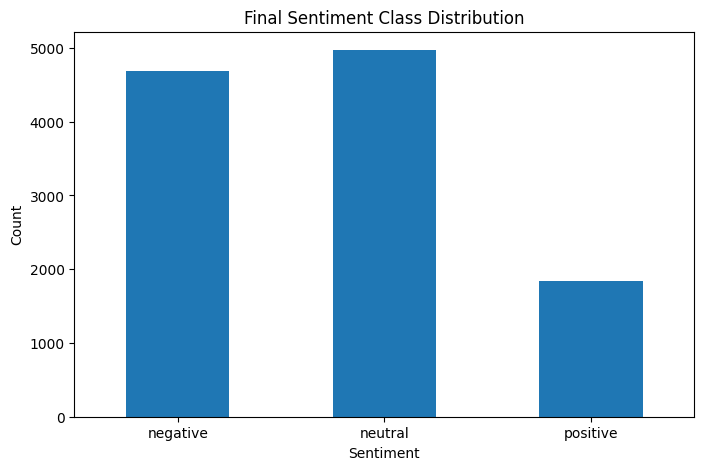

In [27]:
# ---------------------------------------------------------
# Plot the final class distribution
# ---------------------------------------------------------
import matplotlib.pyplot as plt
label_counts_named = final_label_counts.rename(index=label_name_map)

plt.figure(figsize=(8, 5))
label_counts_named.plot(kind="bar")
plt.title("Final Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [28]:
# ---------------------------------------------------------
# Basic length statistics on final merged data
# ---------------------------------------------------------

df_final["text_length_chars"] = df_final["text"].astype(str).str.len()

length_stats = {
    "min_len": int(df_final["text_length_chars"].min()),
    "max_len": int(df_final["text_length_chars"].max()),
    "mean_len": round(df_final["text_length_chars"].mean(), 2),
    "median_len": float(df_final["text_length_chars"].median()),
}

print("Text length stats:")
print(length_stats)

Text length stats:
{'min_len': 1, 'max_len': 2178, 'mean_len': np.float64(55.88), 'median_len': 40.0}


In [29]:
# ---------------------------------------------------------
# Save intermediate cleaned versions of each dataset
# This helps debugging later if something goes wrong
# ---------------------------------------------------------

df1.to_csv(PROCESSED_DATA_DIR / "dataset_1_cleaned.csv", index=False, encoding="utf-8-sig")
df2.to_csv(PROCESSED_DATA_DIR / "dataset_2_cleaned.csv", index=False, encoding="utf-8-sig")
df3.to_csv(PROCESSED_DATA_DIR / "dataset_3_cleaned.csv", index=False, encoding="utf-8-sig")

print("Intermediate cleaned datasets saved.")

Intermediate cleaned datasets saved.


In [30]:
# ---------------------------------------------------------
# Save the final training dataset
# This is the main file we will use for modeling
# ---------------------------------------------------------

final_dataset_path = FINAL_DATA_DIR / "sentiment_dataset_final.csv"
df_final.to_csv(final_dataset_path, index=False, encoding="utf-8-sig")

print("Final canonical dataset saved to:")
print(final_dataset_path)

Final canonical dataset saved to:
C:\Users\hp\Lucidia-project\ml\data\final\sentiment_dataset_final.csv


In [31]:
# ---------------------------------------------------------
# Save metadata for traceability
# ---------------------------------------------------------

metadata = {
    "final_dataset_path": str(final_dataset_path),
    "final_shape": list(df_final.shape),
    "final_label_distribution": final_label_counts.to_dict(),
    "label_mapping_final": {
        "0": "negative",
        "1": "neutral",
        "2": "positive",
    },
    "source_mappings": {
        "dataset_1": {
            "-1": 0,
            "0": 1,
            "1": 2,
        },
        "dataset_2": {
            "1": 0,
            "0": 1,
            "2": 2,
            "11": "removed",
        },
        "dataset_3": {
            "0": 0,
            "1": 1,
            "2": 2,
        },
    },
    "notes": [
        "Unnamed columns removed",
        "Invalid label rows removed",
        "Exact duplicate texts removed within each dataset and globally",
        "Basic text normalization applied",
    ],
}

metadata_path = FINAL_DATA_DIR / "sentiment_dataset_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Metadata saved to:")
print(metadata_path)

Metadata saved to:
C:\Users\hp\Lucidia-project\ml\data\final\sentiment_dataset_metadata.json


In [32]:
# ---------------------------------------------------------
# Final notebook conclusions
# ---------------------------------------------------------

print("Notebook 02 conclusions:")
print("- The 3 datasets were cleaned and standardized.")
print("- Labels were normalized to 0=negative, 1=neutral, 2=positive.")
print("- Invalid labels were removed.")
print("- Useless unnamed columns were dropped.")
print("- Empty rows were removed.")
print("- Duplicate texts were removed.")
print("- Final canonical dataset was saved.")
print("- Ready for Notebook 03: train/validation/test split + baselines.")

Notebook 02 conclusions:
- The 3 datasets were cleaned and standardized.
- Labels were normalized to 0=negative, 1=neutral, 2=positive.
- Invalid labels were removed.
- Useless unnamed columns were dropped.
- Empty rows were removed.
- Duplicate texts were removed.
- Final canonical dataset was saved.
- Ready for Notebook 03: train/validation/test split + baselines.
